# **Projeto de Doenças Cardiovasculares - Regressão Logística**


## 1 Objetivo

Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

Neste projeto iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

cholesterol - colesterol | 1: normal, 2: acima do normal, 3: muito acima do normal

gluc - glicose | 1: normal, 2: acima do normal, 3: muito acima do normal

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

## 2 Carregamento e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


In [2]:
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')

In [3]:
base.head()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62,1,1,0,0,1,0
1,55,1,156,85,3,1,0,0,1,1
2,52,1,165,64,3,1,0,0,0,1
3,48,2,169,82,1,1,0,0,1,1
4,48,1,156,56,1,1,0,0,0,0


In [4]:
# Verificando os tipos de dados
base.dtypes

age               int64
gender            int64
height            int64
weight              str
cholesterol       int64
gluc              int64
smoke             int64
alco              int64
active            int64
cardio_disease    int64
dtype: object

In [5]:
# Verificando valores nulos
base.isnull().sum()

age               0
gender            0
height            0
weight            0
cholesterol       0
gluc              0
smoke             0
alco              0
active            0
cardio_disease    0
dtype: int64

In [6]:
# Removendo os pontos da coluna 'weight'
base['weight'] = base['weight'].str.replace(',', '', regex=False)

# Convertendo a coluna 'weight' de string (str) para inteiro (int64)
base['weight'] = base['weight'].astype(int)

In [7]:
# Verificando se houve a conversão
base.dtypes

age               int64
gender            int64
height            int64
weight            int64
cholesterol       int64
gluc              int64
smoke             int64
alco              int64
active            int64
cardio_disease    int64
dtype: object

In [8]:
# Verifica dados estatíticos das variáveis numéricas
base.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.288300,1.345400,164.308200,75.937300,1.365000,1.222200,0.089000,0.053700,0.797200,0.503100
std,6.796234,0.475522,8.178796,36.867469,0.677658,0.565561,0.284758,0.225436,0.402105,0.500015
min,30.000000,1.000000,70.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,1065.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


- A variável `height` apresenta média de aproximadamente 164 cm, porém possui valores muito baixos e muito altos, como altura mínima de 70 cm e máxima de 250 cm, indicando possíveis inconsistências ou outliers.
- A variável `weight` apresenta média de aproximadamente 75,94 kg, mas possui valor máximo de 1065 kg, muito acima do esperado, indicando presença de outliers ou possíveis erros de preenchimento.
- As variáveis `cholesterol`, `gluc`, `smoke`, `alco`, `active`, `gender` e `cardio_disease` são categóricas ou binárias, portanto não devem ser avaliadas da mesma forma que variáveis contínuas.

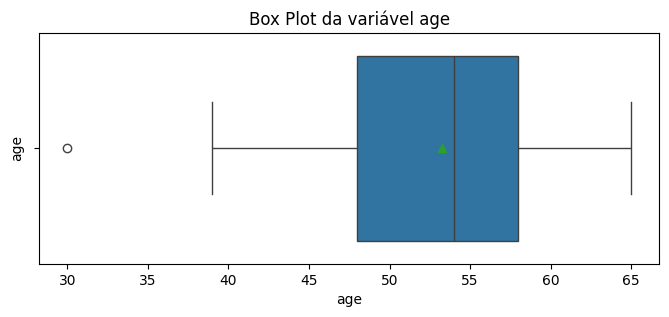

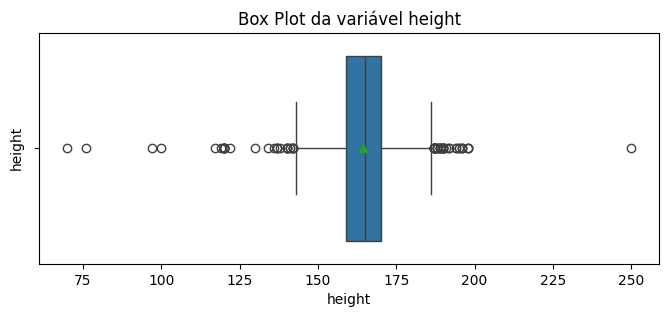

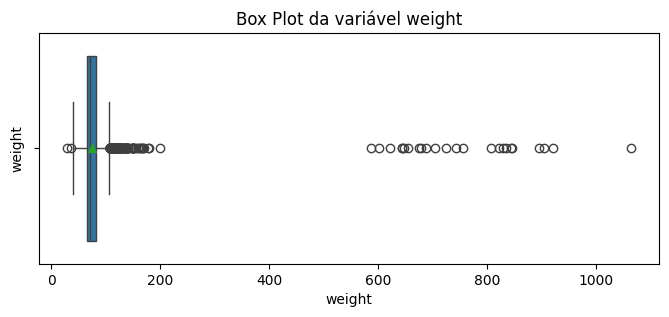

In [9]:
# Boxplot das variáveis numéricas
numerical_cols = ['age', 'height', 'weight']

for col in numerical_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=base[col], showmeans=True)
    plt.title(f'Box Plot da variável {col}')
    plt.ylabel(col)
    plt.show()

Observando os boxplots, é possível identificar a presença de outliers nas variáveis `age`, `height` e `weight`. 

Na variável `age`, há apenas um valor isolado em torno de 30 anos, mas ele ainda parece plausível dentro do contexto dos dados, por isso não necessariamente precisa ser tratado.

Já nas variáveis `height` e `weight`, os outliers são mais expressivos. Existem alturas muito baixas e muito altas, além de pesos extremamente elevados, como valores acima de 500 kg. Esses casos podem representar erros de preenchimento ou inconsistências na base, sendo recomendado realizar o tratamento desses registros antes da modelagem.
    

In [10]:
# Filtrando valores plausíveis para altura e peso
base = base[
    (base['height'] >= 120) & (base['height'] <= 220) &
    (base['weight'] >= 30) & (base['weight'] <= 250)
]

In [11]:
# Verificandos se os valores extremos foram removidos
base.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,9969.000000,9969.000000,9969.000000,9969.000000,9969.000000,9969.000000,9969.000000,9969.000000,9969.000000,9969.000000
mean,53.287592,1.345070,164.343766,74.290501,1.364329,1.221788,0.088675,0.053666,0.797171,0.503160
std,6.795367,0.475415,7.952993,14.543077,0.677306,0.565230,0.284288,0.225369,0.402126,0.500015
min,30.000000,1.000000,120.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,198.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


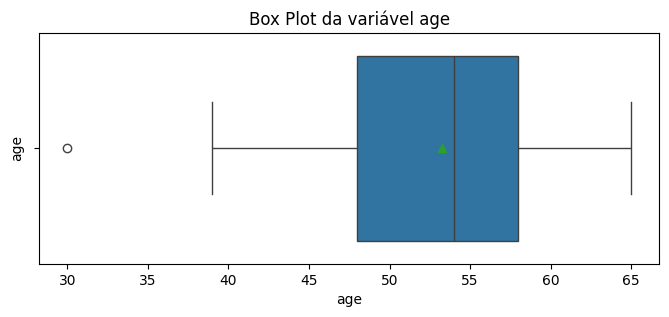

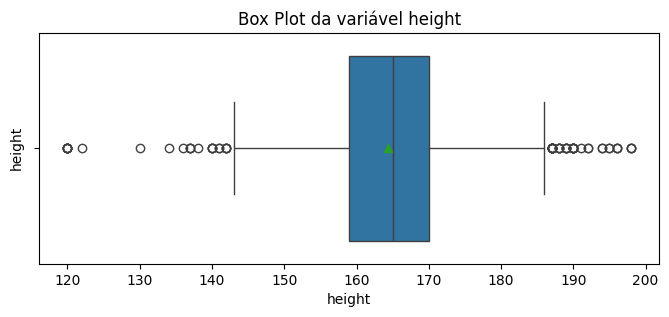

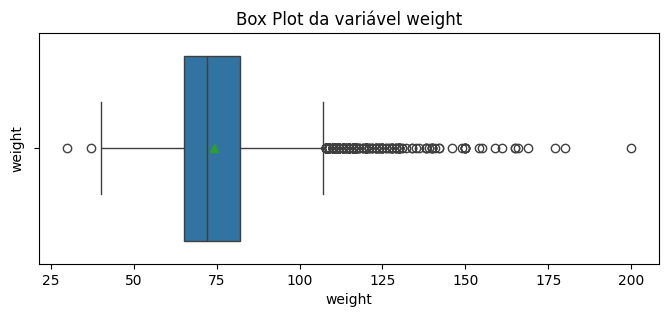

In [12]:
# Verificando se os valores extremos foram removidos
numerical_cols = ['age', 'height', 'weight']

for col in numerical_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=base[col], showmeans=True)
    plt.title(f'Box Plot da variável {col}')
    plt.ylabel(col)
    plt.show()

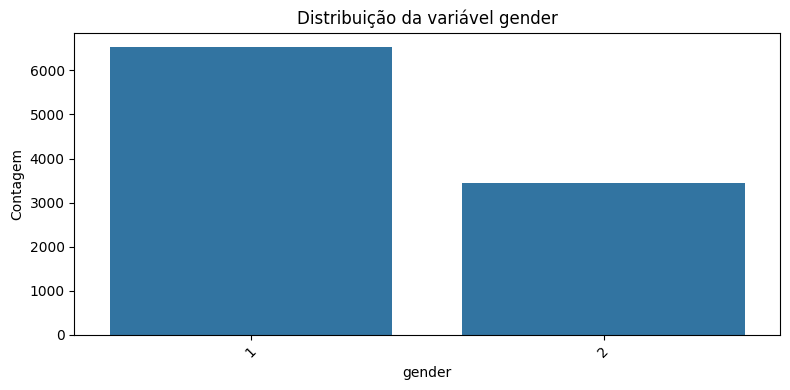


Percentual de gender:
gender
1    65.49
2    34.51
Name: proportion, dtype: float64


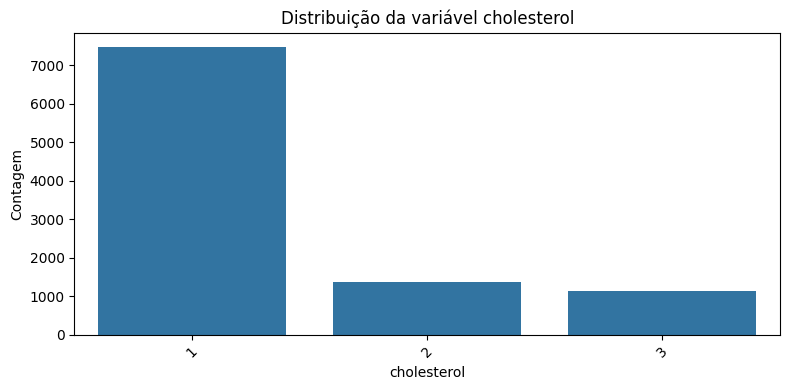


Percentual de cholesterol:
cholesterol
1    74.92
2    13.72
3    11.36
Name: proportion, dtype: float64


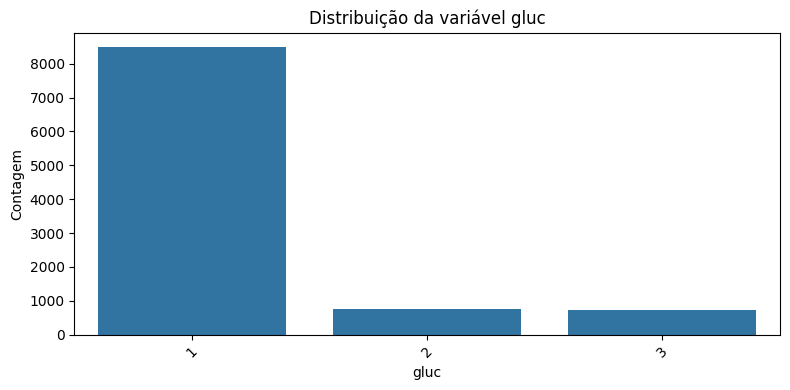


Percentual de gluc:
gluc
1    85.16
2     7.49
3     7.34
Name: proportion, dtype: float64


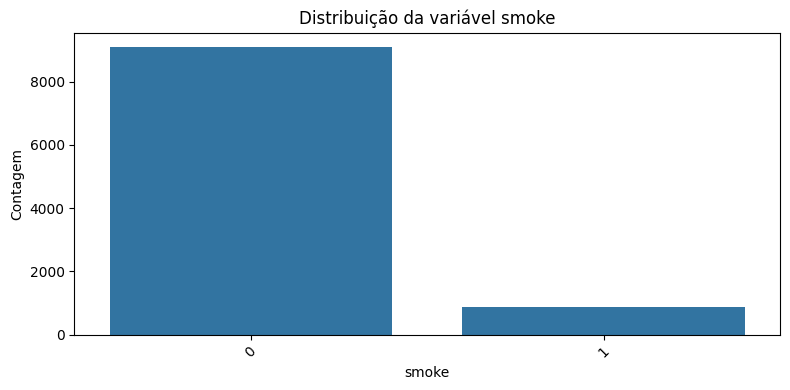


Percentual de smoke:
smoke
0    91.13
1     8.87
Name: proportion, dtype: float64


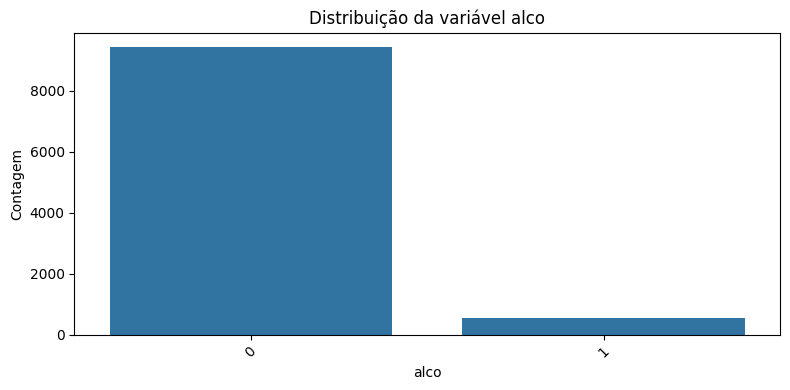


Percentual de alco:
alco
0    94.63
1     5.37
Name: proportion, dtype: float64


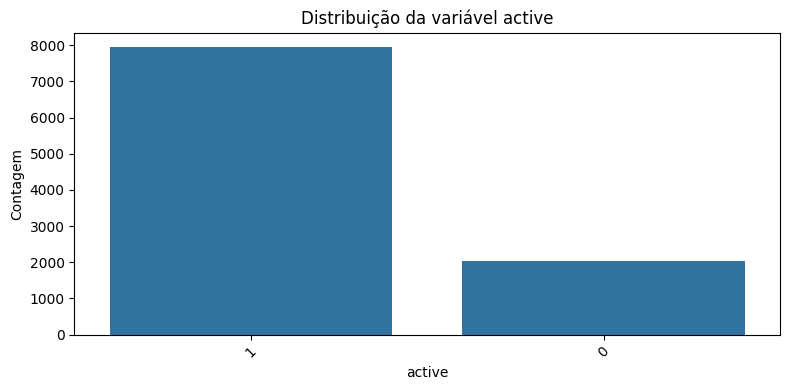


Percentual de active:
active
1    79.72
0    20.28
Name: proportion, dtype: float64


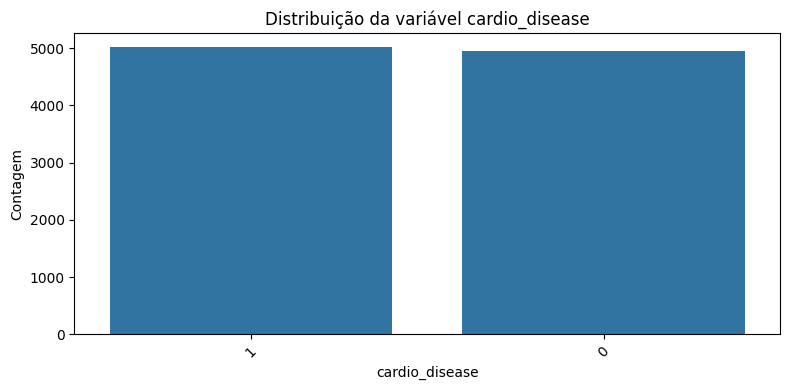


Percentual de cardio_disease:
cardio_disease
1    50.32
0    49.68
Name: proportion, dtype: float64


In [13]:
cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio_disease']

for col in cols:
    plt.figure(figsize=(8,4))
    order = base[col].value_counts().index
    sns.countplot(data=base, x=col, order=order)
    plt.title(f'Distribuição da variável {col}')
    plt.xticks(rotation=45)
    plt.ylabel('Contagem')
    plt.tight_layout()
    plt.show()

    print(f'\nPercentual de {col}:')
    print((base[col].value_counts(normalize=True) * 100).round(2))

Os gráficos de contagem mostram a distribuição das variáveis categóricas e binárias da base de dados.

- A variável `gender` não está igualmente distribuída. A categoria 1, referente aos homens, aparece em maior proporção na base, representando aproximadamente 65,49% dos registros, enquanto a categoria 2, referente às mulheres, representa aproximadamente 34,51%.
- A variável `cholesterol` apresenta predominância da categoria 1, considerada normal, com 74,92% dos registros. As categorias 2 e 3 aparecem em menor proporção, representando 13,72% e 11,36%, respectivamente.
- A variável `gluc` também apresenta predominância da categoria 1, considerada normal, com 85,16% dos registros. As categorias 2 e 3 representam 7,49% e 7,34%.
- A variável `smoke` mostra que a maior parte dos indivíduos não fuma, representando 91,13% da base.
- A variável `alco` indica que a maioria dos indivíduos não consome álcool, com 94,63% dos registros.
- A variável `active` mostra que a maior parte dos indivíduos pratica atividade física, representando 79,72% da base.
- A variável alvo `cardio_disease` está praticamente balanceada, com 50,32% dos registros indicando presença de doença cardiovascular e 49,68% indicando ausência. Esse equilíbrio é positivo para a etapa de modelagem, pois reduz o risco de viés causado por desbalanceamento da variável alvo.

## 3 Exploração e Análise dos Dados

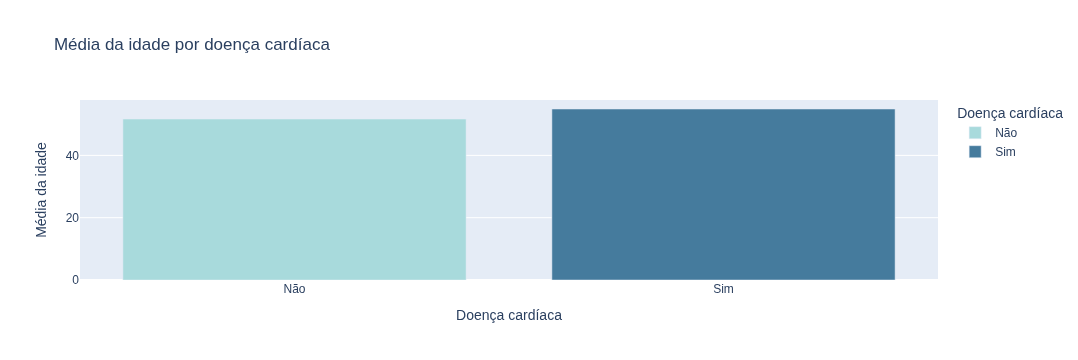

In [14]:
mean_age_by_cardio_disease = base.groupby('cardio_disease')['age'].mean().reset_index()

mean_age_by_cardio_disease['cardio_disease'] = mean_age_by_cardio_disease['cardio_disease'].map({
    0: 'Não',
    1: 'Sim'
})

fig = px.bar(
    mean_age_by_cardio_disease,
    x='cardio_disease',
    y='age',
    title='Média da idade por doença cardíaca',
    labels={
        'age': 'Média da idade',
        'cardio_disease': 'Doença cardíaca'
    },
    color='cardio_disease',
    color_discrete_map={
        'Não': '#a8dadc',
        'Sim': '#457b9d'
    }
)

fig.update_layout(
    legend_title_text='Doença cardíaca'
)

fig.show()

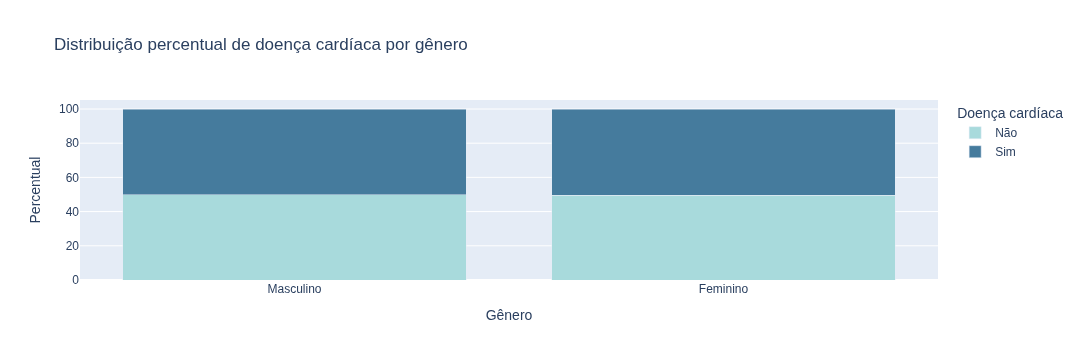

In [15]:
base_grouped = base.groupby(['gender', 'cardio_disease']).size().reset_index(name='count')

# Trocar 0 e 1 por Não e Sim
base_grouped['gender'] = base_grouped['gender'].map({
    1: 'Masculino',
    2: 'Feminino'
})

# Ajustando cardio_disease para texto
base_grouped['cardio_disease'] = base_grouped['cardio_disease'].map({
    0: 'Não',
    1: 'Sim'
})

base_grouped['percent'] = base_grouped.groupby('gender')['count'].transform(
    lambda x: x / x.sum() * 100
)

fig = px.bar(
    base_grouped,
    x='gender',
    y='percent',
    color='cardio_disease',
    barmode='stack',
    title='Distribuição percentual de doença cardíaca por gênero',
    labels={
        'gender': 'Gênero',
        'percent': 'Percentual',
        'cardio': 'Doença cardíaca'
    },
    color_discrete_map={
        'Não': '#a8dadc',
        'Sim': '#457b9d'
    }
)

# Alterando o nome da legenda
fig.update_layout(
    legend_title_text='Doença cardíaca'
)

fig.show()

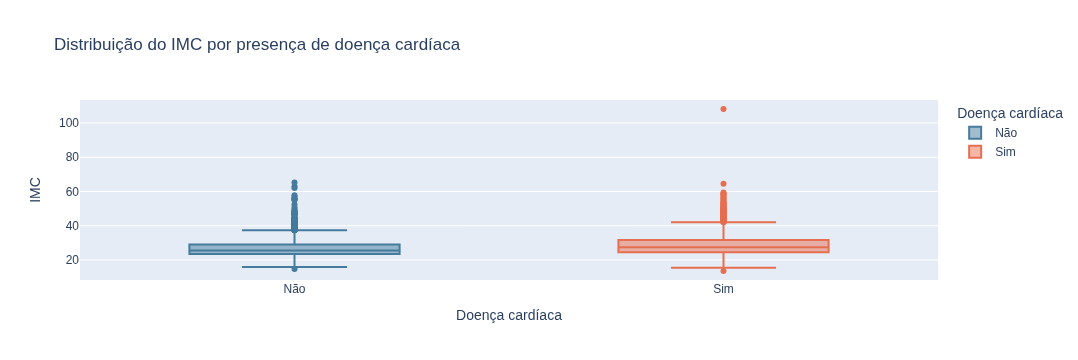

In [16]:
base_imc = base.copy()

base_imc['imc'] = base_imc['weight'] / ((base_imc['height'] / 100) ** 2)

base_imc['cardio_disease'] = base_imc['cardio_disease'].map({
    0: 'Não',
    1: 'Sim'
})

fig = px.box(
    base_imc,
    x='cardio_disease',
    y='imc',
    color='cardio_disease',
    title='Distribuição do IMC por presença de doença cardíaca',
    labels={
        'cardio_disease': 'Doença cardíaca',
        'imc': 'IMC'
    },
    color_discrete_sequence=['#457b9d', '#e76f51']
)

fig.show()

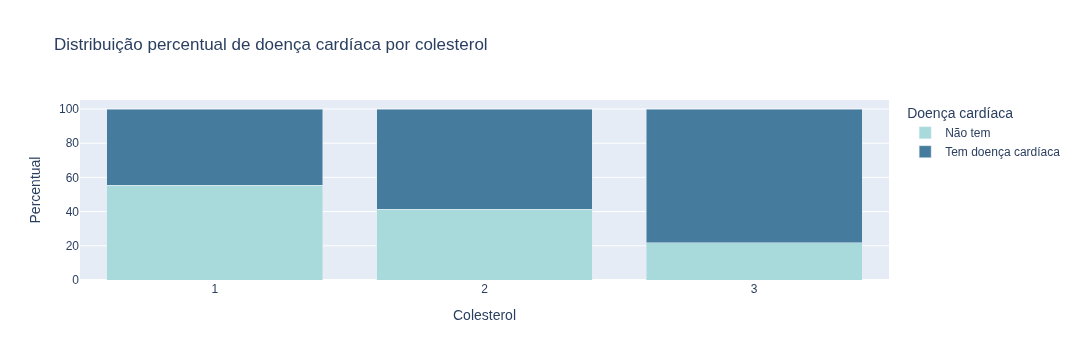

In [17]:
base_cholesterol = base.groupby(['cholesterol', 'cardio_disease']).size().reset_index(name='count')

# Ajustando cardio_disease para texto
base_cholesterol['cardio_disease'] = base_cholesterol['cardio_disease'].map({
    0: 'Não tem',
    1: 'Tem doença cardíaca'
})

base_cholesterol['percent'] = base_cholesterol.groupby('cholesterol')['count'].transform(
    lambda x: x / x.sum() * 100
)

fig = px.bar(
    base_cholesterol,
    x='cholesterol',
    y='percent',
    color='cardio_disease',
    barmode='stack',
    title='Distribuição percentual de doença cardíaca por colesterol',
    color_discrete_sequence=['#a8dadc', '#457b9d'],
    labels={
        'cholesterol': 'Colesterol',
        'percent': 'Percentual',
        'cardio_disease': 'Doença cardíaca'
    },
    
)

fig.show()

Na análise bivariada, foi possível observar diferenças no comportamento da variável `cardio_disease` em relação a outras variáveis da base.

O gráfico da média de idade mostra que os indivíduos com doença cardíaca apresentam idade média maior em comparação aos indivíduos sem doença cardíaca. Isso indica que a presença da doença tende a ser mais frequente em pacientes mais velhos.

Ao analisar o IMC, observa-se que o grupo com doença cardíaca apresenta uma distribuição ligeiramente superior, sugerindo que o peso corporal em relação à altura pode ter alguma relação com a presença da condição.

No gráfico percentual por colesterol, percebe-se que a proporção de indivíduos com doença cardíaca aumenta conforme o nível de colesterol passa de normal para acima do normal e muito acima do normal. Isso indica que a variável `cholesterol` pode ser relevante para o modelo.

De modo geral, as variáveis `age`, `imc` e `cholesterol` apresentaram associações mais perceptíveis com a variável alvo `cardio_disease`.

## 4 Matriz de Correlação



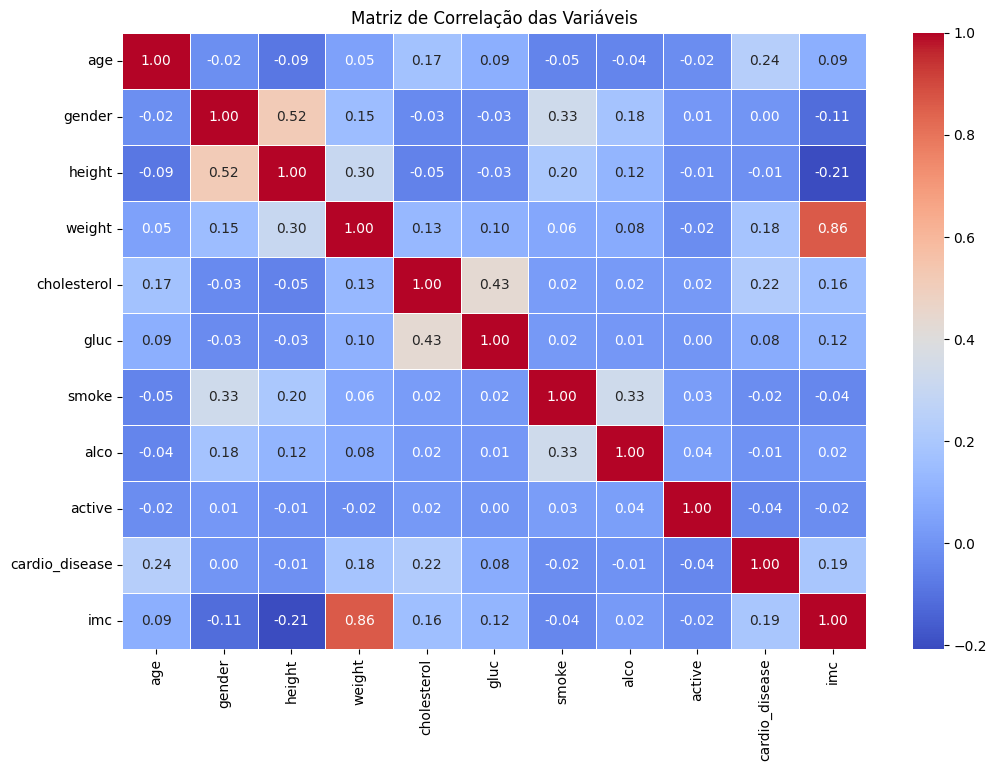

In [18]:
# Criando a coluna IMC, caso ainda não tenha sido criada
base['imc'] = base['weight'] / ((base['height'] / 100) ** 2)

# Matriz de correlação
corr = base.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Matriz de Correlação das Variáveis')
plt.show()

A matriz de correlação permite observar a força e a direção do relacionamento entre as variáveis numéricas da base.

Em relação à variável alvo `cardio_disease`, as maiores correlações positivas foram observadas com `age`, `cholesterol`, `imc` e `weight`. A variável `age` apresentou correlação de aproximadamente 0,24 com a presença de doença cardíaca, indicando que pacientes mais velhos tendem a apresentar maior ocorrência da doença. A variável `cholesterol` também apresentou correlação positiva, aproximadamente 0,22, sugerindo associação entre níveis mais altos de colesterol e presença de doença cardiovascular.

A variável `imc` apresentou correlação positiva de aproximadamente 0,19 com `cardio_disease`, enquanto `weight` apresentou correlação de aproximadamente 0,18. Como `weight` e `imc` possuem uma correlação forte entre si, de aproximadamente 0,86, pode ser interessante utilizar apenas o `imc` na modelagem, evitando redundância entre variáveis.

Também se observa correlação moderada entre `cholesterol` e `gluc`, aproximadamente 0,43, indicando que pacientes com colesterol mais elevado também tendem a apresentar níveis mais altos de glicose. Já variáveis como `gender`, `smoke`, `alco` e `active` apresentaram correlações muito baixas com a variável alvo, sugerindo uma relação linear pouco evidente nesta base.

## 5 Separação da base em treino e teste

In [19]:
# Separando em X (variáveis de entrada) e Y (variável de saída)
X = base[['age', 'gender', 'imc', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']]
y = base['cardio_disease']
X

,age,gender,imc,cholesterol,gluc,smoke,alco,active
0,50,2,21.967120,1,1,0,0,1
1,55,1,34.927679,3,1,0,0,1
2,52,1,23.507805,3,1,0,0,0
3,48,2,28.710479,1,1,0,0,1
4,48,1,23.011177,1,1,0,0,0
...,...,...,...,...,...,...,...,...
9995,56,1,23.588329,1,1,0,0,0
9996,50,1,36.328125,2,1,0,0,1
9997,40,1,26.438071,2,2,0,0,1
9998,50,1,24.801587,3,1,0,0,1


In [20]:
# Verificando balanceamento do dados antes de separarmos em treino e teste
base['cardio_disease'].value_counts()

cardio_disease
1    5016
0    4953
Name: count, dtype: int64

In [21]:
# Separar em base de treino e teste (usando 80% para treino e 20% para teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

In [22]:
# Inicializar StandardScaler
scaler= StandardScaler()

# Ajustando e transformando os dados de treino
X_train_scaled = scaler.fit_transform(X_train)

# Transformando os dados de teste usando os parâmetros aprendidos dos dados de treino
X_test_scaled = scaler.transform(X_test)

# Transformando em DataFrame para facilitar visualização
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print('\nDistribuição no treino:')
print(y_train.value_counts(normalize=True) * 100)

print('\nDistribuição no teste:')
print(y_test.value_counts(normalize=True) * 100)

print('\nVisualização de X_train:')
display(X_train_scaled.head())

print('\nVisualização de X_test:')
display(X_test_scaled.head())



Distribuição no treino:
cardio_disease
1    50.319749
0    49.680251
Name: proportion, dtype: float64

Distribuição no teste:
cardio_disease
1    50.300903
0    49.699097
Name: proportion, dtype: float64

Visualização de X_train:


,age,gender,imc,cholesterol,gluc,smoke,alco,active
0,-0.481584,-0.717640,-1.006347,-0.540962,-0.391926,-0.308977,-0.238141,0.504502
1,-0.775874,1.393456,-0.026567,-0.540962,-0.391926,-0.308977,-0.238141,0.504502
2,0.106996,-0.717640,-0.473140,0.933465,1.380968,-0.308977,-0.238141,0.504502
3,0.548431,-0.717640,-0.679987,-0.540962,-0.391926,-0.308977,-0.238141,0.504502
4,-0.775874,-0.717640,0.067870,-0.540962,-0.391926,-0.308977,4.199188,0.504502



Visualização de X_test:


,age,gender,imc,cholesterol,gluc,smoke,alco,active
0,-0.187294,-0.717640,0.012275,-0.540962,-0.391926,-0.308977,-0.238141,0.504502
1,0.106996,1.393456,0.338108,-0.540962,-0.391926,-0.308977,-0.238141,0.504502
2,-1.805889,1.393456,-0.795673,-0.540962,-0.391926,-0.308977,-0.238141,0.504502
3,0.989866,1.393456,2.172077,-0.540962,1.380968,-0.308977,-0.238141,0.504502
4,0.989866,-0.717640,-1.166273,0.933465,-0.391926,-0.308977,-0.238141,0.504502


A base foi separada em treino e teste, utilizando 80% dos dados para treinamento e 20% para teste. Foi utilizado o parâmetro `stratify=y` para manter a mesma proporção da variável alvo nas duas bases.

A padronização foi realizada porque a regressão logística é sensível à escala das variáveis. Como existem variáveis em escalas diferentes, como idade, IMC, colesterol e glicose, a padronização contribui para que o modelo interprete melhor os coeficientes.

Ao verificar a distribuição da variável `cardio_disease`, observa-se que a base está balanceada, com proporções próximas entre as classes 0 e 1. Por isso, não foi necessário aplicar técnicas de balanceamento.

## 6 Treinamento do modelo

In [23]:
# Criando e treinando o modelo
logistics_model = LogisticRegression(random_state=0)

logistics_model.fit(X_train_scaled, y_train)

# Intercepto
print('Intercepto:')
print(logistics_model.intercept_)

# Coeficientes
coefficients = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': logistics_model.coef_[0]
})

coefficients = coefficients.sort_values(by='Coeficiente', ascending=False)

coefficients

Intercepto:
[0.03060449]


,Variável,Coeficiente
3,cholesterol,0.428797
0,age,0.423520
2,imc,0.341916
1,gender,0.090498
6,alco,-0.000101
5,smoke,-0.030157
4,gluc,-0.052789
7,active,-0.089806


In [24]:
# Previsões na base de treino
predictions_train = logistics_model.predict(X_train_scaled)

print('\nRelatório de classificação:')
print(classification_report(y_train, predictions_train))


Relatório de classificação:
              precision    recall  f1-score   support

           0       0.63      0.67      0.65      3962
           1       0.65      0.61      0.63      4013

    accuracy                           0.64      7975
   macro avg       0.64      0.64      0.64      7975
weighted avg       0.64      0.64      0.64      7975



Na base de treino, o modelo apresentou desempenho moderado, com acurácia em torno de 0,64. As métricas de precisão, recall e F1-score ficaram próximas entre as classes 0 e 1, indicando que o modelo não favoreceu fortemente apenas uma das categorias. Esse resultado mostra que a regressão logística conseguiu identificar alguns padrões nos dados, mas ainda possui limitações para separar corretamente todos os casos.

## 7 Teste do Modelo

In [25]:
predictions_test = logistics_model.predict(X_test_scaled)

In [26]:
report_test= classification_report(y_test, predictions_test)
print("Relatório de Classificação:")
print(report_test)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.63      0.67      0.65       991
           1       0.65      0.61      0.63      1003

    accuracy                           0.64      1994
   macro avg       0.64      0.64      0.64      1994
weighted avg       0.64      0.64      0.64      1994



In [27]:
probabilities_test = logistics_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, probabilities_test)

roc_auc = roc_auc_score(y_test, probabilities_test)

print("AUC: {:.2f}".format(roc_auc))

AUC: 0.69


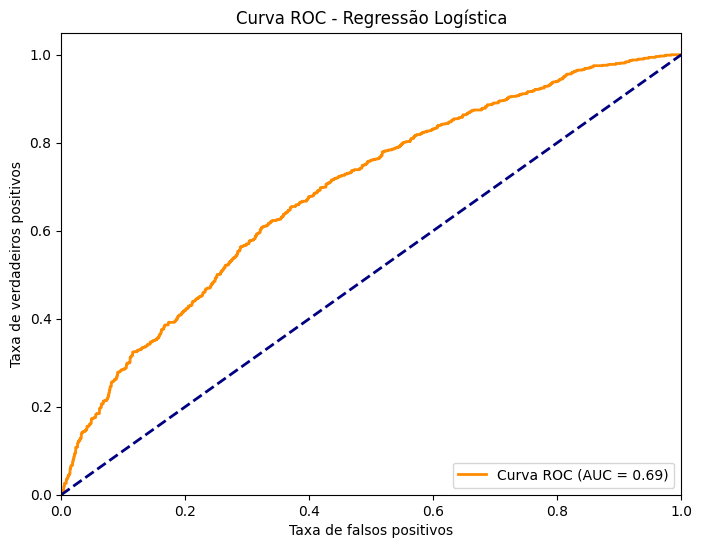

In [28]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de falsos positivos')
plt.ylabel('Taxa de verdadeiros positivos')
plt.title('Curva ROC - Regressão Logística')
plt.legend(loc='lower right')
plt.show()

Na base de teste, o modelo apresentou desempenho semelhante ao observado na base de treino, com acurácia em torno de 0,64. Isso indica que o modelo não apresenta sinais fortes de overfitting, pois o desempenho nos dados não vistos ficou próximo ao desempenho obtido no treinamento.

A curva ROC foi construída com as probabilidades previstas pelo modelo. A métrica AUC foi de aproximadamente 0,69, indicando que o modelo possui capacidade de separação superior ao acaso, mas ainda moderada. Portanto, o modelo consegue identificar alguns padrões relacionados à presença de doença cardiovascular, porém ainda pode ser melhorado com novas variáveis, ajustes nos atributos ou comparação com outros modelos de classificação.

## 8 Explicação e Considerações Finais


A regressão logística é um modelo estatístico utilizado para prever a probabilidade de ocorrência de uma determinada classe. Neste caso, ela é usada para estimar a probabilidade de uma pessoa possuir ou não doença cardíaca com base em variáveis como idade, IMC, colesterol, glicose, tabagismo, consumo de álcool e prática de atividade física.

A regressão logística é considerada um modelo de classificação porque sua saída é usada para separar os registros em classes. Embora o modelo calcule uma probabilidade, essa probabilidade é convertida em uma classe final, geralmente usando o ponto de corte de 0,5. Assim, se a probabilidade for maior ou igual a 0,5, o modelo classifica como presença de doença cardíaca; caso contrário, classifica como ausência.

A regressão logística tem pontos em comum com a regressão linear, pois ambas utilizam coeficientes para medir a influência das variáveis explicativas sobre a variável resposta. No entanto, enquanto a regressão linear prevê valores contínuos, a regressão logística é usada para prever probabilidades e realizar classificações.

De modo geral, a regressão logística apresentou desempenho razoável para um modelo inicial de classificação de doença cardiovascular. As variáveis com maior influência positiva no modelo foram colesterol, idade e IMC, o que está de acordo com os padrões observados na análise exploratória. Apesar de o modelo não apresentar desempenho alto, ele conseguiu resultados superiores ao acaso e pode servir como uma primeira abordagem para o problema.